# Load packages

In [47]:
import scanpy as sc
import matplotlib.pyplot as plt

In [48]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from combat.pycombat import pycombat
import matplotlib.pyplot as plt

In [49]:
from scipy import stats

# Load Data

In [6]:
UTAG_adata = sc.read('/Volumes/Expansion/Auria/UTAG_data_AllMarkers_Percore.h5ad')

In [7]:
UTAG_adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'CellID', 'imageid', 'max_dist_30_leiden_0.2'
    uns: 'max_dist_30_leiden_0.2', 'neighbors', 'pca'
    obsm: 'X_pca', 'max_dist_30_leiden_0.2_probabilities', 'spatial'
    varm: 'PCs'
    layers: 'log'
    obsp: 'connectivities', 'distances'

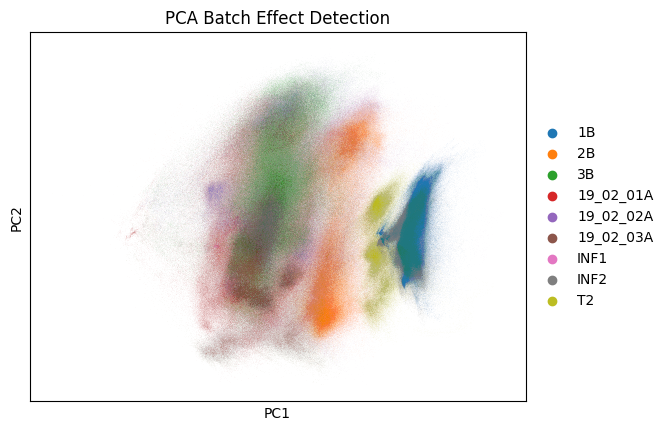

In [9]:
sc.pl.pca_scatter(UTAG_adata, color=['imageid'], title='PCA Batch Effect Detection')

In [ ]:
sc.pl.pca_scatter(UTAG_adata, color=['core_imageid'], title='PCA Batch Effect Detection')

In [ ]:
sc.pl.pca_scatter(UTAG_adata, color=['patient_id_AB19_1654'], title='Patients', color_map='viridis')

In [ ]:

# Extract marker data
marker_data = pd.DataFrame(UTAG_adata.X, columns=UTAG_adata.var_names)
marker_data['imageid'] = UTAG_adata.obs['imageid'].values

# Perform ANOVA
anova_results = {}
for marker in UTAG_adata.var_names:
    grouped = [group[marker].values for _, group in marker_data.groupby('imageid')]
    f_val, p_val = stats.f_oneway(*grouped)
    anova_results[marker] = p_val

# Filter significant markers
anova_results = pd.Series(anova_results)
significant_markers = anova_results[anova_results < 0.05]
print(f"There are {len(significant_markers)} markers that are significantly different between batches")


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Extract slide labels
slide_labels = UTAG_adata.obs['imageid'].astype('category').cat.codes  
correlations = {}

for marker in UTAG_adata.var_names:
    corr, p_val = spearmanr(UTAG_adata.X[:, UTAG_adata.var_names == marker].flatten(), slide_labels)
    correlations[marker] = (corr, p_val)

# Filter significant markers
correlations = pd.DataFrame(correlations, index=['Spearman_corr', 'p_value']).T
significant_corrs = correlations[correlations['p_value'] < 0.05]
print(f"There are {len(significant_corrs)} markers that are significantly different between batches")


# Remove Batch effect

In [19]:
UTAG_adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,max_dist_30_leiden_0.2
19_02_02A_1,2027.642,1011.238,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.821700,failed_classify,failed_classify,failed_classify,failed_classify,---,1,19_02_02A,96
19_02_02A_10,1999.424,1195.504,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.755401,NQO1_pos,failed_classify,failed_classify,failed_classify,+--,10,19_02_02A,96
19_02_02A_100,1728.540,1302.083,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.522613,failed_classify,failed_classify,failed_classify,failed_classify,---,100,19_02_02A,96
19_02_02A_1000,1563.067,1768.670,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,345,0.699640,failed_classify,failed_classify,failed_classify,failed_classify,---,1000,19_02_02A,96
19_02_02A_1001,1589.079,1770.373,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,365,0.807719,failed_classify,failed_classify,failed_classify,failed_classify,---,1001,19_02_02A,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3B_891018,28756.200,27477.100,core34_3B,core34,Other,Tumor center,1,AB19-1654_P10616,503,0.592382,failed_classify,failed_classify,failed_classify,failed_classify,--+,891018,3B,6
3B_891019,28875.170,27474.000,core34_3B,core34,Myofibroblasts,Tumor center,1,AB19-1654_P10616,285,0.645940,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,891019,3B,6
3B_891020,28830.660,27479.190,core34_3B,core34,Other,Tumor center,1,AB19-1654_P10616,416,0.793394,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,891020,3B,6
3B_891021,28741.290,27475.540,core34_3B,core34,Other,Tumor center,1,AB19-1654_P10616,103,0.796034,failed_classify,failed_classify,failed_classify,failed_classify,--+,891021,3B,6


In [51]:
data = pd.read_csv('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Data_AllMarkers_filtered.csv')

/var/folders/g1/q5dj_hvs3hg185qg1n_llr7r0000gn/T/ipykernel_94509/2491250662.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Data_AllMarkers_filtered.csv')


In [52]:
data.columns

Index(['CellID', 'S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid',
       'imageid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1',
       'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1',
       'antioxidant_GLUT1', 'NQO1_GCLC_VIM'],
      dtype='object')

In [53]:
data_matrix = data[['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1']]

In [54]:
data_matrix

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,E.Cadherin,GCLC,TXNRD1,NQO1,pERK,TXN,pSTAT3,pS6_235,pRB,GLUT1
0,0.587351,0.668424,0.197573,0.119095,0.357855,0.221494,0.351031,0.261670,0.120537,0.641891,...,0.072933,0.170813,0.233933,0.133212,0.561163,0.686848,0.116407,0.219205,0.228998,0.257643
1,0.711467,0.738836,0.522747,0.185507,0.275963,0.214838,0.374685,0.350623,0.029450,0.608733,...,0.597589,0.288927,0.574179,0.920970,0.594473,0.650463,0.140063,0.177884,0.346786,0.254725
2,0.803970,0.824031,0.331924,0.204348,0.355699,0.234078,0.518679,0.390894,0.161177,0.666724,...,0.089716,0.392473,0.330708,0.527165,0.606849,0.724070,0.504031,0.288863,0.316182,0.352457
3,0.744246,0.762114,0.531392,0.185345,0.246533,0.227313,0.392369,0.348677,0.023832,0.619029,...,0.586083,0.278554,0.515391,0.864835,0.596698,0.597501,0.125361,0.198205,0.259981,0.384413
4,0.796639,0.796858,0.357244,0.192493,0.431782,0.228827,0.489430,0.380457,0.156145,0.674359,...,0.089637,0.377826,0.293672,0.444848,0.596879,0.723559,0.206866,0.283895,0.297867,0.378596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681767,0.832069,0.723583,0.638020,0.130660,0.135379,0.173406,0.316902,0.220026,0.366662,0.634752,...,0.544210,0.456331,0.452719,0.446660,0.870571,0.861278,0.483556,0.478148,0.402705,0.438617
3681768,0.770561,0.929819,0.451729,0.390374,0.620998,0.488494,0.532568,0.522331,0.467017,0.871813,...,0.495976,0.640434,0.499728,0.422046,0.851141,0.845426,0.487575,0.637049,0.466327,0.452710
3681769,0.678946,0.721054,0.228812,0.598502,0.598347,0.229858,0.528080,0.499220,0.232839,0.704152,...,0.215578,0.526600,0.475171,0.421663,0.854832,0.827554,0.477796,0.457762,0.452349,0.452095
3681770,0.845231,0.699380,0.353627,0.224872,0.146464,0.184371,0.271080,0.261490,0.140438,0.615633,...,0.522123,0.288315,0.278148,0.409337,0.594288,0.687225,0.221027,0.115578,0.149392,0.230927


## pycombat

In [55]:
data_matrix = data_matrix.T
batch = data['imageid']
corrected_data = pycombat(data_matrix, batch)

Found 9 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


In [56]:
print(f"data_matrix shape: {data_matrix.shape}")
print(f"batch shape: {batch.shape}")

data_matrix shape: (25, 3681772)
batch shape: (3681772,)


In [ ]:
corrected_data_2 = corrected_data.T
plt.boxplot(corrected_data_2)

## z-score all images

In [34]:
z_scored_data = (corrected_data_2 - corrected_data_2.mean(axis=0)) / corrected_data_2.std(axis=0)
z_scored_data = np.clip(z_scored_data, -3, 3)

In [35]:
z_scored_data

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,E.Cadherin,GCLC,TXNRD1,NQO1,pERK,TXN,pSTAT3,pS6_235,pRB,GLUT1
0,-2.553995,-1.397482,-1.355589,-1.876681,0.237268,-0.621908,-0.914259,0.222224,-1.092286,-0.134991,...,-1.802133,-2.684043,-1.324928,-1.064254,-2.124341,1.342161,-0.358682,-1.223755,0.104882,-1.066852
1,0.100205,0.736267,0.274412,-1.037039,-0.173026,-0.293021,0.066863,1.816127,-1.786715,-0.989080,...,1.068837,-1.074744,3.000000,2.822614,0.013980,1.719681,-0.103804,-1.265394,3.000000,-0.624234
2,0.021486,1.247237,-0.466183,-1.189530,0.221334,-0.440247,1.317348,1.486209,-0.759571,0.443569,...,-1.703478,-0.640184,0.277387,1.251682,-0.023550,2.246363,2.759398,-0.502362,1.777390,-0.172345
3,0.547985,1.220700,0.341362,-1.038496,-0.383876,0.019979,0.296661,1.783961,-1.858050,-0.547505,...,0.981404,-1.168434,2.120832,2.543837,0.136905,0.292799,-0.283402,-1.012807,2.137084,0.885003
4,-0.065666,0.785396,-0.298564,-1.285081,0.783442,-0.516045,0.928004,1.384128,-0.800766,0.621441,...,-1.703940,-0.775241,-0.335819,0.767764,-0.481980,2.233951,0.368977,-0.553811,1.426040,0.074259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681767,0.350048,0.212014,1.221394,-0.870325,-1.283617,-0.099135,-0.470170,-0.642285,0.672360,-0.177329,...,1.004071,-1.031232,0.798677,-0.447438,-0.296790,0.556257,-0.081553,0.036758,-0.746370,0.065198
3681768,0.310592,0.167350,-0.876509,-0.272166,0.897550,-0.005490,0.387096,0.465484,-0.011481,0.073186,...,-0.473506,1.912337,0.457843,-0.430901,0.357235,0.241001,0.141973,1.053145,0.082821,-0.282653
3681769,-1.003891,-1.668330,-1.623654,2.351641,1.734148,-0.356135,2.648408,3.000000,-0.697156,1.025968,...,-1.310463,0.577628,-0.142825,-0.313407,0.388773,0.288460,-0.034231,0.405849,0.079704,-0.224115
3681770,0.631055,-0.020310,-0.231792,-0.771992,-1.440385,-0.248864,-0.908272,-0.427137,-1.624504,-0.279532,...,0.788991,-0.998869,-0.322138,0.501732,-0.012034,1.136268,-1.721767,-1.387797,-0.102863,-0.892800


In [ ]:
means = z_scored_data.mean(axis=0)
stds = z_scored_data.std(axis=0)


print("Means:\n", means)
print("Standard Deviations:\n", stds)

mean_close_to_zero = np.all(np.abs(means) < 1e-5)
std_close_to_one = np.all(np.abs(stds - 1) < 1e-5)

print('Is the mean close to 0:', mean_close_to_zero)
print('Is the standard Deviation close to 1:', std_close_to_one)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe997562580>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe997562ac0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe9975622e0>,
 'medians': [<matplotlib.lines.Line2D at 0x7fe997562fd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fe9975742e0>,
 'means': []}

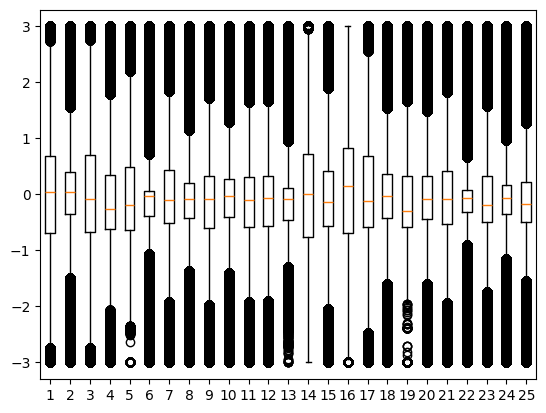

In [38]:

plt.boxplot(z_scored_data)

In [39]:
data_2 = data
data_2.iloc[:, 1:26] = z_scored_data
data_2

,CellID,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,...,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM
0,1,-2.553995,-1.397482,-1.355589,-1.876681,0.237268,-0.621908,-0.914259,0.222224,-1.092286,...,2,AB19-1654_P10158,282,0.821700,Other,failed_classify,failed_classify,failed_classify,failed_classify,---
1,10,0.100205,0.736267,0.274412,-1.037039,-0.173026,-0.293021,0.066863,1.816127,-1.786715,...,2,AB19-1654_P10117,258,0.620470,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--
2,10,0.021486,1.247237,-0.466183,-1.189530,0.221334,-0.440247,1.317348,1.486209,-0.759571,...,2,AB19-1654_P10158,125,0.755401,CD68.Macrophages,NQO1_pos,failed_classify,failed_classify,failed_classify,+--
3,100,0.547985,1.220700,0.341362,-1.038496,-0.383876,0.019979,0.296661,1.783961,-1.858050,...,2,AB19-1654_P10117,222,0.803584,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--
4,100,-0.065666,0.785396,-0.298564,-1.285081,0.783442,-0.516045,0.928004,1.384128,-0.800766,...,2,AB19-1654_P10158,300,0.522613,Immune,failed_classify,failed_classify,failed_classify,failed_classify,---
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681767,99998,0.350048,0.212014,1.221394,-0.870325,-1.283617,-0.099135,-0.470170,-0.642285,0.672360,...,unknown,AB19-1654_P10648,148,0.641780,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---
3681768,99999,0.310592,0.167350,-0.876509,-0.272166,0.897550,-0.005490,0.387096,0.465484,-0.011481,...,2,AB19-1654_P10561,366,0.771436,FOXP3.CD4.Tregs,failed_classify,GCLC_pos,failed_classify,failed_classify,-++
3681769,99999,-1.003891,-1.668330,-1.623654,2.351641,1.734148,-0.356135,2.648408,3.000000,-0.697156,...,2,AB19-1654_P10599,558,0.863484,CD4.T.cells,failed_classify,GCLC_pos,failed_classify,failed_classify,-++
3681770,99999,0.631055,-0.020310,-0.231792,-0.771992,-1.440385,-0.248864,-0.908272,-0.427137,-1.624504,...,1,AB19-1654_P10620,112,0.883622,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---


In [ ]:
data_2.to_csv('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Data_AllMarkers_filtered_corrected.csv', index=False)

In [42]:
# Extract marker data
markers = data_2.columns[1:26]

# Extract imageid
imageid = data_2['imageid']

# Perform ANOVA
anova_results = {}
for marker in markers:
    grouped = [group[marker].values for _, group in data_2.groupby('imageid')]
    f_val, p_val = stats.f_oneway(*grouped)
    anova_results[marker] = p_val

# Filter significant markers
anova_results = pd.Series(anova_results)
significant_markers = anova_results[anova_results < 0.05]
print(f"There are {len(significant_markers)} markers that are significantly different between batches")

There are 20 markers that are significantly different between batches


## z-score per image

In [58]:
corrected_data_2 = corrected_data.T
corrected_data_2

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,E.Cadherin,GCLC,TXNRD1,NQO1,pERK,TXN,pSTAT3,pS6_235,pRB,GLUT1
0,0.584712,0.748313,0.336291,0.167524,0.383382,0.293096,0.337191,0.320251,0.245877,0.691393,...,0.267735,0.254383,0.354567,0.271304,0.704035,0.740366,0.341917,0.296650,0.309175,0.317911
1,0.767025,0.812171,0.508312,0.247026,0.339084,0.306925,0.396798,0.402995,0.197337,0.676625,...,0.555330,0.379460,0.477965,0.707592,0.712802,0.744925,0.350118,0.293526,0.397162,0.353852
2,0.761618,0.827463,0.430154,0.232587,0.381661,0.300735,0.472770,0.385868,0.269134,0.701397,...,0.277617,0.413235,0.398230,0.531260,0.712648,0.751286,0.442243,0.350777,0.344928,0.390545
3,0.797782,0.826669,0.515378,0.246888,0.316319,0.320086,0.410759,0.401325,0.192351,0.684260,...,0.546572,0.372179,0.448463,0.676300,0.713306,0.727692,0.344339,0.312478,0.352618,0.476402
4,0.755631,0.813641,0.447844,0.223540,0.442350,0.297547,0.449116,0.380569,0.266254,0.704473,...,0.277571,0.402738,0.381520,0.476941,0.710769,0.751136,0.365330,0.346917,0.337418,0.410570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681767,0.784186,0.796481,0.608251,0.262811,0.219177,0.315078,0.364171,0.275372,0.369225,0.690661,...,0.548842,0.382842,0.412435,0.340539,0.711528,0.730874,0.350833,0.391228,0.290978,0.409834
3681768,0.781476,0.795145,0.386851,0.319448,0.454670,0.319015,0.416254,0.332880,0.321425,0.694993,...,0.400828,0.611622,0.403147,0.342395,0.714209,0.727066,0.358026,0.467489,0.308703,0.381588
3681769,0.691186,0.740207,0.308001,0.567883,0.544995,0.304271,0.553637,0.507408,0.273497,0.711467,...,0.316987,0.507886,0.386779,0.355584,0.714339,0.727640,0.352356,0.418922,0.308637,0.386341
3681770,0.803488,0.789528,0.454891,0.272121,0.202251,0.308782,0.337555,0.286541,0.208676,0.688894,...,0.527297,0.385357,0.381893,0.447080,0.712696,0.737879,0.298058,0.284342,0.304734,0.332044


In [59]:
data_3 = data
data_3.iloc[:, 1:26] = corrected_data_2
data_3

,CellID,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,...,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM
0,1,0.584712,0.748313,0.336291,0.167524,0.383382,0.293096,0.337191,0.320251,0.245877,...,2,AB19-1654_P10158,282,0.821700,Other,failed_classify,failed_classify,failed_classify,failed_classify,---
1,10,0.767025,0.812171,0.508312,0.247026,0.339084,0.306925,0.396798,0.402995,0.197337,...,2,AB19-1654_P10117,258,0.620470,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--
2,10,0.761618,0.827463,0.430154,0.232587,0.381661,0.300735,0.472770,0.385868,0.269134,...,2,AB19-1654_P10158,125,0.755401,CD68.Macrophages,NQO1_pos,failed_classify,failed_classify,failed_classify,+--
3,100,0.797782,0.826669,0.515378,0.246888,0.316319,0.320086,0.410759,0.401325,0.192351,...,2,AB19-1654_P10117,222,0.803584,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--
4,100,0.755631,0.813641,0.447844,0.223540,0.442350,0.297547,0.449116,0.380569,0.266254,...,2,AB19-1654_P10158,300,0.522613,Immune,failed_classify,failed_classify,failed_classify,failed_classify,---
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681767,99998,0.784186,0.796481,0.608251,0.262811,0.219177,0.315078,0.364171,0.275372,0.369225,...,unknown,AB19-1654_P10648,148,0.641780,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---
3681768,99999,0.781476,0.795145,0.386851,0.319448,0.454670,0.319015,0.416254,0.332880,0.321425,...,2,AB19-1654_P10561,366,0.771436,FOXP3.CD4.Tregs,failed_classify,GCLC_pos,failed_classify,failed_classify,-++
3681769,99999,0.691186,0.740207,0.308001,0.567883,0.544995,0.304271,0.553637,0.507408,0.273497,...,2,AB19-1654_P10599,558,0.863484,CD4.T.cells,failed_classify,GCLC_pos,failed_classify,failed_classify,-++
3681770,99999,0.803488,0.789528,0.454891,0.272121,0.202251,0.308782,0.337555,0.286541,0.208676,...,1,AB19-1654_P10620,112,0.883622,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---


In [60]:
data_3.columns

Index(['CellID', 'S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid',
       'imageid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1',
       'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1',
       'antioxidant_GLUT1', 'NQO1_GCLC_VIM'],
      dtype='object')

In [ ]:
imageids = ['19_02_02A', '19_02_01A', 'T2', 'INF2', '19_02_03A', '1B', '2B', '3B', 'INF1']
marker_columns = ['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1']

# Calculate z-scores
for imageid in imageids:
       data_3_subset = data_3[data_3['imageid'] == imageid]
       data_3_subset_expression = data_3_subset[marker_columns]
       z_scored_data = (data_3_subset_expression - data_3_subset_expression.mean(axis=0)) / data_3_subset_expression.std(axis=0)
       z_scored_data = np.clip(z_scored_data, -3, 3)



In [62]:
marker_columns = ['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1']

for marker in marker_columns:
    data_3[f'{marker}_z_score'] = data_3.groupby('imageid')[marker].transform(lambda x: stats.zscore(x))

In [68]:
data_3.columns

Index(['CellID', 'S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid',
       'imageid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1',
       'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1',
       'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'S9.6_z_score', 'HER3_z_score',
       'panCK_z_score', 'SMA_z_score', 'CD45_z_score', 'Ki67_2_z_score',
       'CD4_z_score', 'FOXP3_z_score', 'CD8a_z_score', 'CD11b_z_score',
       'CD68_z_score', 'CD206_z_score', 'H2ax_z_score', 'Vimentin_z_score',
       'H3K27me3_z_score', 'E.Cadherin_z_score', 'GCLC_z_score',
       'TXNRD1_z_score', 'NQO1_z_score', 'pERK_z_score', 'TXN_z_score',
       'pSTAT3_z_score', 'pS6_235_z_score', 'pRB_z_score'

In [76]:
data_3_zscore = data_3[['CellID', 'S9.6_z_score', 'HER3_z_score',
       'panCK_z_score', 'SMA_z_score', 'CD45_z_score', 'Ki67_2_z_score',
       'CD4_z_score', 'FOXP3_z_score', 'CD8a_z_score', 'CD11b_z_score',
       'CD68_z_score', 'CD206_z_score', 'H2ax_z_score', 'Vimentin_z_score',
       'H3K27me3_z_score', 'E.Cadherin_z_score', 'GCLC_z_score',
       'TXNRD1_z_score', 'NQO1_z_score', 'pERK_z_score', 'TXN_z_score',
       'pSTAT3_z_score', 'pS6_235_z_score', 'pRB_z_score', 'GLUT1_z_score',
       'X_centroid', 'Y_centroid', 'imageid', 'core_imageid', 'cores.x', 
       'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654',
       'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM']]

In [77]:
data_3_zscore.to_csv('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Data_AllMarkers_filtered_corrected_perimage.csv', index=False)

In [75]:
data_2.columns

Index(['CellID', 'S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid',
       'imageid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1',
       'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1',
       'antioxidant_GLUT1', 'NQO1_GCLC_VIM'],
      dtype='object')

In [78]:
data_3_zscore.columns

Index(['CellID', 'S9.6_z_score', 'HER3_z_score', 'panCK_z_score',
       'SMA_z_score', 'CD45_z_score', 'Ki67_2_z_score', 'CD4_z_score',
       'FOXP3_z_score', 'CD8a_z_score', 'CD11b_z_score', 'CD68_z_score',
       'CD206_z_score', 'H2ax_z_score', 'Vimentin_z_score', 'H3K27me3_z_score',
       'E.Cadherin_z_score', 'GCLC_z_score', 'TXNRD1_z_score', 'NQO1_z_score',
       'pERK_z_score', 'TXN_z_score', 'pSTAT3_z_score', 'pS6_235_z_score',
       'pRB_z_score', 'GLUT1_z_score', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1',
       'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1',
       'antioxidant_GLUT1', 'NQO1_GCLC_VIM'],
      dtype='object')